In [1]:
#SL-Assignment-2
# Name: Ashlesha Tayade                Name: Ruchika Gaikwad
# PRN:260240128008                     PRN:260240128036

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

In [3]:
data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [4]:
X = data.data
y = data.target

X.shape, y.shape

((442, 10), (442,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
alphas = np.logspace(-4, 4, 100)

models = {
    "RidgeCV": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=alphas, cv=5))
    ]),
    "LassoCV": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42))
    ]),
    "ElasticNetCV": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            alphas=alphas,
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            cv=5,
            max_iter=10000,
            random_state=42
        ))
    ])
}

In [7]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,RMSE,MSE,R2
1,LassoCV,52.923989,2800.948639,0.471335
2,ElasticNetCV,53.466064,2858.620030,0.460450
0,RidgeCV,53.470523,2859.096862,0.460360


In [8]:
for name, model in models.items():
    fitted = model.named_steps["model"]
    print(f"\n{name}")
    print("Best alpha:", fitted.alpha_)
    if name == "ElasticNetCV":
        print("Best l1_ratio:", fitted.l1_ratio_)


RidgeCV
Best alpha: 37.649358067924716

LassoCV
Best alpha: 1.592282793341094

ElasticNetCV
Best alpha: 0.1176811952434999
Best l1_ratio: 0.1


In [9]:
print(results_df)

          Model       RMSE          MSE        R2
1       LassoCV  52.923989  2800.948639  0.471335
2  ElasticNetCV  53.466064  2858.620030  0.460450
0       RidgeCV  53.470523  2859.096862  0.460360


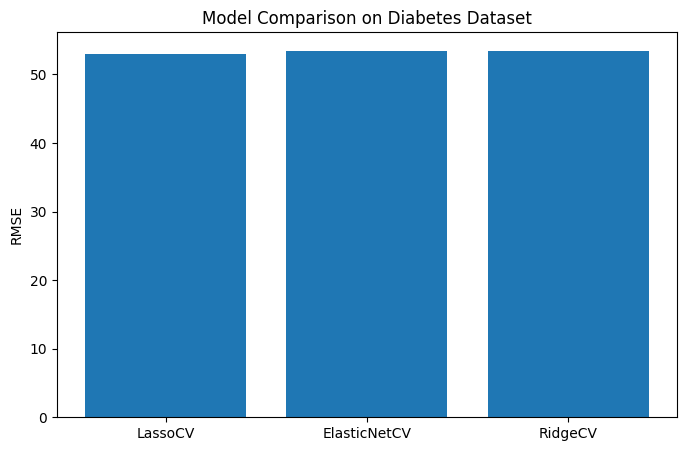

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison on Diabetes Dataset")
plt.show()